# Benchmark Retrieval Methods for RAG (TF-IDF vs BM25 vs Dense vs Hybrid)

## Импорт библиотек

In [2]:
pip install langchain_text_splitters langchain_community faiss-cpu nltk rank-bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
import re
import ast
import random
from dataclasses import dataclass
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModel,
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
)
from sklearn.metrics.pairwise import cosine_similarity

from rank_bm25 import BM25Okapi

from langchain_core.documents import Document

from langchain_text_splitters import (
    MarkdownHeaderTextSplitter,
    RecursiveCharacterTextSplitter,
)

from langchain_community.vectorstores import FAISS

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'rank_bm25'

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

DEVICE: cuda


## Конфиг

In [4]:
CSV_PATH = "data/train_data.csv"

EMBEDDER_MODEL_NAME = (
    "ai-forever/sbert_large_nlu_ru"
)

CHUNK_SIZE = 1024
CHUNK_OVERLAP = 100

TOP_K = 5

HYBRID_ALPHA = 0.5

## Загрузка и обработка данных

In [5]:
def load_docs(file_path: str,) -> List[Document]:

    df = pd.read_csv(file_path)
    documents = []

    for _, row in df.iterrows():

        tags = row.get("tags", [])
        if isinstance(tags, str):
            try:
                tags = ast.literal_eval(tags)
            except Exception:
                tags = [tags]

        metadata = {
            "id": row["id"],
            "tags": tags,
        }

        documents.append(
            Document(
                page_content=row["text"],
                metadata=metadata,
            )
        )

    return documents

documents = load_docs(CSV_PATH)

print("Documents loaded:", len(documents))

NameError: name 'Document' is not defined

In [7]:
# documents = documents[:100]
# documents

### Препроцессинг

In [8]:
def remove_update_timestamps(text: str,) -> str:

    pattern = (
        r"^\\s*Обновлено "
        r"\\d{2}\\.\\d{2}\\.\\d{4} "
        r"в \\d{2}:\\d{2}\\s*$"
    )

    cleaned_lines = [
        line
        for line in text.splitlines()
        if not re.fullmatch(pattern, line)
    ]

    return "\\n".join(cleaned_lines)


def is_header_only_chunk(doc: Document, ) -> bool:

    content = doc.page_content.strip()

    if not content:
        return True
    if re.fullmatch(r"#{1,6}\\s+.+", content):
        return True

    lines = [line.strip() for line in content.splitlines() if line.strip()]

    if (len(lines) == 1 and re.match(r"#{1,6}\\s+.+", lines[0])):
        return True

    return False

### Чанкование

In [9]:
def split_documents(
    documents: List[Document],
    chunk_size: int = 1024,
    chunk_overlap: int = 100,
) -> List[Document]:

    headers_to_split_on = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
        ("####", "Header 4"),
        ("#####", "Header 5"),
    ]

    markdown_splitter = (
        MarkdownHeaderTextSplitter(
            headers_to_split_on=headers_to_split_on,
            strip_headers=False,
        )
    )

    recursive_splitter = (
        RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=["\\n\\n", "\\n", " ", "",],
        )
    )

    all_chunks = []
    for doc in documents:

        text = remove_update_timestamps(doc.page_content)
        md_chunks = markdown_splitter.split_text(text)

        for md_chunk in md_chunks:
            combined_metadata = (doc.metadata.copy())

            combined_metadata.update(md_chunk.metadata)
            md_chunk.metadata = combined_metadata

        md_chunks = [
            chunk
            for chunk in md_chunks
            if not is_header_only_chunk(chunk)
        ]

        final_chunks = []
        for chunk in md_chunks:

            if len(chunk.page_content) > chunk_size:
                sub_chunks = (
                    recursive_splitter.create_documents(
                        texts=[chunk.page_content],
                        metadatas=[chunk.metadata],
                    )
                )

                final_chunks.extend(sub_chunks)

            else:
                final_chunks.append(chunk)

        all_chunks.extend(final_chunks)

    for idx, chunk in enumerate(all_chunks):
      chunk.metadata["chunk_id"] = idx

    return all_chunks


all_chunks = split_documents(
    documents=documents,
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

print("Chunks:", len(all_chunks))

Chunks: 3897


## Бенчмарк вопросы

In [10]:
benchmark_queries = [
    {
        "query": "Какие есть ставки налога для самозанятых в зависимости от типа покупателя?",
        "relevant_doc_id": "doc_001",
    },
    {
        "query": "Что будет человеку, если он переведет социальное пособие с одного счета на другой, и можно ли будет вернуть деньги?",
        "relevant_doc_id": "doc_002",
    },
    {
        "query": "Почему не стоит брать кредит в первом попавшемся банке и на какие параметры надо обратить внимание?",
        "relevant_doc_id": "doc_003",
    },
    {
        "query": "В чем разница между брокером и доверительным управляющим, и что лучше подойдет новичку?",
        "relevant_doc_id": "doc_004",
    },
    {
        "query": "Если микрофинансовую организацию исключили из государственного реестра, нужно ли заемщику возвращать долг, и кому именно следует платить?",
        "relevant_doc_id": "doc_005",
    },
    {
        "query": "Какую книгу Александр Лахтиков рекомендует для освоения современных подходов к управлению?",
        "relevant_doc_id": "doc_006",
    },
    {
        "query": "Чем сервис оплаты частями принципиально отличается от потребительского кредита с точки зрения законодательного регулирования?",
        "relevant_doc_id": "doc_007",
    },
    {
        "query": "Что такое структурный продукт с полной защитой капитала, и какие риски остаются у инвестора?",
        "relevant_doc_id": "doc_008",
    },
    {
        "query": "Как совместная закупка канцелярских принадлежностей с другими родителями класса поможет сэкономить семейный бюджет при подготовке к школе?",
        "relevant_doc_id": "doc_009",
    },
    {
        "query": "При каком условии полис ДСАГО начинает действовать и покрывать ущерб, причиненный чужому автомобилю?",
        "relevant_doc_id": "doc_010",
    },
    {
        "query": "Обязан ли самозанятый платить страховые взносы на пенсионное и медицинское страхование, и что будет с его пенсией, если он не делает этого?",
        "relevant_doc_id": "doc_001",
    },
    {
        "query": "В какой срок необходимо подать в банк заявление о возврате ошибочно списанной социальной выплаты, если в маркировке платежа был указан верный код дохода?",
        "relevant_doc_id": "doc_002",
    },
    {
        "query": "Что делать заемщику, который оказался в сложной финансовой ситуации и не может внести очередной платеж по ипотеке, чтобы избежать штрафов?",
        "relevant_doc_id": "doc_003",
    },
    {
        "query": "Какую информацию о доверительном управляющем обязательно должна содержать маркировка на его сайте в поисковых системах «Яндекс» или Mail.ru?",
        "relevant_doc_id": "doc_004",
    },
    {
        "query": "Может ли новый кредитор, купивший долг у исключенной из реестра МФО, изменить условия договора займа?",
        "relevant_doc_id": "doc_005",
    },
    {
        "query": "Как BNPL-сервисы влияют на кредитную историю покупателя, и с каким риском это связано?",
        "relevant_doc_id": "doc_007",
    },
    {
        "query": "Какие документы от виновника и потерпевшего необходимо предоставить в страховую компанию для получения выплаты по ДСАГО?",
        "relevant_doc_id": "doc_010",
    },
    {
        "query": "Что следует сделать после внесения последнего платежа по кредиту, чтобы убедиться, что долг действительно закрыт?",
        "relevant_doc_id": "doc_003",
    },
    {
        "query": "Почему не рекомендуется спешить с покупкой школьной формы в августе?",
        "relevant_doc_id": "doc_009",
    },
    {
        "query": "Какие категории граждан и виды деятельности не имеют права претендовать на получение статуса самозанятого?",
        "relevant_doc_id": "doc_001",
    },
    {
        "query": "В течение какого срока после ДТП, оформленного по европротоколу, необходимо передать извещение о ДТП в страховую компанию?",
        "relevant_doc_id": "doc_011"
    },
    {
        "query": "Какие существуют риски при инвестировании в недвижимость для получения пассивного дохода?",
        "relevant_doc_id": "doc_012"
    },
    {
        "query": "Что такое ипотечные каникулы и кто имеет право на их получение?",
        "relevant_doc_id": "doc_013"
    },
    {
        "query": "Какие существуют способы получить налоговый вычет на долгосрочные сбережения?",
        "relevant_doc_id": "doc_014"
    },
    {
        "query": "Что делать заемщику, если бюро кредитных историй, было исключено из реестра Банка России, и он хочет оспорить ошибку в своей кредитной истории?",
        "relevant_doc_id": "doc_015"
    },
    {
        "query": "Как рассчитать свою личную инфляцию, чтобы она отличалась от официальной статистики Росстата?",
        "relevant_doc_id": "doc_016"
    },
    {
        "query": "Каков максимальный размер взноса для получения налогового вычета на ИИС-3 за год и как он рассчитывается?",
        "relevant_doc_id": "doc_017"
    },
    {
        "query": "Какие последствия грозят человеку, если его банковская карта была использована мошенниками для перевода украденных денег, и его внесли в базу дропперов Банка России?",
        "relevant_doc_id": "doc_018"
    },
    {
        "query": "Может ли подросток в возрасте 14 лет самостоятельно открыть банковский вклад?",
        "relevant_doc_id": "doc_019"
    },
    {
        "query": "Как проверить туроператора при покупке тура, чтобы не стать жертвой мошенников, предлагающих несуществующие путевки?",
        "relevant_doc_id": "doc_020"
    },
    {
        "query": "Какие мобильные приложения помогают учитывать траты в путешествии, сканируя чеки или подключая банковскую карту?",
        "relevant_doc_id": "doc_021"
    },
    {
        "query": "Какие существуют способы не поддаваться на маркетинговые уловки в магазинах и не совершать импульсивные покупки?",
        "relevant_doc_id": "doc_022"
    },
    {
        "query": "Каковы условия для оформления внесудебного банкротства, если судебные приставы не нашли имущества для взыскания долга?",
        "relevant_doc_id": "doc_023"
    },
    {
        "query": "Какую информацию из личного кабинета на портале «Госуслуги» можно предоставить банку с помощью цифрового профиля для получения кредита?",
        "relevant_doc_id": "doc_024"
    },
    {
        "query": "Что означает попадание компании в зону высокого риска на информационной платформе «Знай своего клиента» (ЗСК) и к каким последствиям это приводит?",
        "relevant_doc_id": "doc_025"
    },
    {
        "query": "Какой совет дается в статье для тех, кто хочет сэкономить на подарках и упаковке во время подготовки к Новому году?",
        "relevant_doc_id": "doc_026"
    },
    {
        "query": "Что такое условная и безусловная франшиза при страховании имущества и как она влияет на размер страховой выплаты?",
        "relevant_doc_id": "doc_027"
    },
    {
        "query": "Чем отличаются права и обязанности созаемщика от прав и обязанностей поручителя по кредиту?",
        "relevant_doc_id": "doc_028"
    },
    {
        "query": "Какие основные преимущества и недостатки использования аккредитива по сравнению с банковской ячейкой для безопасных расчетов по сделкам?",
        "relevant_doc_id": "doc_029"
    },
    {
        "query": "Какой первый шаг рекомендуется сделать семье для оптимизации семейного бюджета, прежде чем начинать планировать траты?",
        "relevant_doc_id": "doc_030"
    },
    {
        "query": "Какие мобильные приложения для путешествий позволяют конвертировать валюту и работать в офлайн-режиме?",
        "relevant_doc_id": "doc_021"
    },
    {
        "query": "Почему аренда квартиры в крупном городе может быть выгоднее, чем покупка в ипотеку, с точки зрения разумного потребления?",
        "relevant_doc_id": "doc_022"
    },
    {
        "query": "Какие долги не могут быть списаны даже после успешного завершения процедуры внесудебного банкротства?",
        "relevant_doc_id": "doc_023"
    },
    {
        "query": "Какие дополнительные меры безопасности рекомендуется настроить для учетной записи на «Госуслугах», чтобы защитить цифровой профиль от мошенников?",
        "relevant_doc_id": "doc_024"
    },
    {
        "query": "В какой срок Межведомственная комиссия (МВК) должна рассмотреть заявление предпринимателя об обжаловании блокировки счета по 115-ФЗ?",
        "relevant_doc_id": "doc_025"
    },
    {
        "query": "Какой совет дается в статье относительно покупки сувениров с символикой наступающего года?",
        "relevant_doc_id": "doc_026"
    },
    {
        "query": "Какие документы необходимо предоставить в страховую компанию для оформления договора страхования имущества?",
        "relevant_doc_id": "doc_027"
    },
    {
        "query": "Влияет ли финансовая дисциплина и доход поручителя на сумму кредита и процентную ставку для основного заемщика?",
        "relevant_doc_id": "doc_028"
    },
    {
        "query": "Какие данные должен указать покупатель в заявлении на открытие аккредитива в банке?",
        "relevant_doc_id": "doc_029"
    },
    {
        "query": "Какую сумму от общего дохода эксперты рекомендуют в первую очередь откладывать в «резервный фонд» семейного бюджета?",
        "relevant_doc_id": "doc_030"
    },
    {
        "query": "Чем отличается дебетовая карта от кредитной, и что такое овердрафт?",
        "relevant_doc_id": "doc_031"
    },
    {
        "query": "Где можно быстро получить деньги на развитие бизнеса, если банк не дает кредит?",
        "relevant_doc_id": "doc_032"
    },
    {
        "query": "Если меня мобилизовали, можно ли не платить по кредитам и что для этого нужно сделать?",
        "relevant_doc_id": "doc_033"
    },
    {
        "query": "Правда ли, что можно заработать на разнице кодов рубля 810 и 643?",
        "relevant_doc_id": "doc_034"
    },
    {
        "query": "Мобилизовали, а у меня свой бизнес. Что будет с налогами и арендой?",
        "relevant_doc_id": "doc_035"
    },
    {
        "query": "Как проверить приложение, чтобы не нарваться на мошенников и не потерять деньги?",
        "relevant_doc_id": "doc_036"
    },
    {
        "query": "Меня обманули в телеграм-боте, куда бежать и можно ли вернуть деньги?",
        "relevant_doc_id": "doc_037"
    },
    {
        "query": "Кто такой созаемщик и чем он отличается от поручителя простыми словами?",
        "relevant_doc_id": "doc_038"
    },
    {
        "query": "Стоит ли рефинансировать ипотеку, если ставки стали ниже, и как это сделать?",
        "relevant_doc_id": "doc_039"
    },
    {
        "query": "Когда лучше взять заем в МФО, а не в банке, и какие там есть виды займов?",
        "relevant_doc_id": "doc_040"
    },
    {
        "query": "Какие карты бывают моментальными, а какие требуют времени на оформление?",
        "relevant_doc_id": "doc_031"
    },
    {
        "query": "Как получить льготный микрозаем для бизнеса под низкий процент от государства?",
        "relevant_doc_id": "doc_032"
    },
    {
        "query": "Если военный погиб в ходе СВО, спишут ли его кредиты его семье?",
        "relevant_doc_id": "doc_033"
    },
    {
        "query": "Почему в номере моего счета стоит код 810, и что это значит?",
        "relevant_doc_id": "doc_034"
    },
    {
        "query": "Могут ли мобилизованного ИП заставить закрыть бизнес, если по закону военным нельзя работать?",
        "relevant_doc_id": "doc_035"
    },
    {
        "query": "Правда ли, что в официальном магазине приложений не бывает вирусов и обмана?",
        "relevant_doc_id": "doc_036"
    },
    {
        "query": "Если полиция отказалась возбуждать дело о мошенничестве, куда жаловаться дальше?",
        "relevant_doc_id": "doc_037"
    },
    {
        "query": "Какие документы нужны, чтобы взять кредит с созаемщиком?",
        "relevant_doc_id": "doc_038"
    },
    {
        "query": "Что такое аннуитетные платежи и почему из-за них рефинансирование становится невыгодным в конце срока кредита?",
        "relevant_doc_id": "doc_039"
    },
    {
        "query": "Сколько максимум я переплачу, если просрочу микрозаем?",
        "relevant_doc_id": "doc_040"
    },
    {
        "query": "Если я начинающий инвестор, зачем мне вообще нужен брокер и можно ли без него?",
        "relevant_doc_id": "doc_041"
    },
    {
        "query": "Мне пришло письмо на почту с суперскидкой на маркетплейсе, можно переходить по ссылке?",
        "relevant_doc_id": "doc_042"
    },
    {
        "query": "Я слышал, что в кризис выгодно покупать золото. Это правда и оно всегда растет?",
        "relevant_doc_id": "doc_043"
    },
    {
        "query": "Чем отличается КАСКО от ОСАГО, и если у меня одно КАСКО, покроет ли оно ущерб, если я сам виноват в аварии?",
        "relevant_doc_id": "doc_044"
    },
    {
        "query": "У меня плохая кредитная история, в банках отказывают. Стоит ли обращаться к кредитному брокеру, который обещает помочь?",
        "relevant_doc_id": "doc_045"
    },
    {
        "query": "Мне позвонили из банка и сказали, что пытаются украсть деньги, и просят назвать код из СМС. Это нормально?",
        "relevant_doc_id": "doc_046"
    },
    {
        "query": "Говорят, что если три года не платить по кредиту и скрываться, то долг сгорит. Это правда?",
        "relevant_doc_id": "doc_047"
    },
    {
        "query": "Я продаю вещи через интернет. Безопасно ли указывать в объявлении номер своей банковской карты, чтобы покупатели сразу переводили деньги?",
        "relevant_doc_id": "doc_048"
    },
    {
        "query": "Нашел старую советскую сберкнижку. Могу ли я сейчас получить за нее компенсацию и куда идти?",
        "relevant_doc_id": "doc_049"
    },
    {
        "query": "Что такое самозапрет на кредиты и как он может защитить меня от мошенников?",
        "relevant_doc_id": "doc_050"
    },
    {
        "query": "Если брокер, через которого я торгую, вдруг лишится лицензии, что станет с моими деньгами и акциями?",
        "relevant_doc_id": "doc_041"
    },
    {
        "query": "Мне предложили легкий заработок на маркетплейсе: просто заказывать товары и получать проценты. Это не обман?",
        "relevant_doc_id": "doc_042"
    },
    {
        "query": "Куда выгоднее вложиться: в золото или в акции золотодобывающих компаний?",
        "relevant_doc_id": "doc_043"
    },
    {
        "query": "Если я купил КАСКО, в каких случаях страховая может отказать в выплате?",
        "relevant_doc_id": "doc_044"
    },
    {
        "query": "Кредитный брокер говорит, что может улучшить мою кредитную историю за деньги. Это вообще реально?",
        "relevant_doc_id": "doc_045"
    },
    {
        "query": "Как распознать мошенника по телефону? Какие фразы и действия должны сразу насторожить?",
        "relevant_doc_id": "doc_046"
    },
    {
        "query": "Если я объявлю себя банкротом, то все долги просто спишут, и я ничего не буду должен?",
        "relevant_doc_id": "doc_047"
    },
    {
        "query": "При продаже товара покупатель перевел деньги через приложение банка у меня на глазах, но на мою карту они не пришли. Стоило ли отдавать товар?",
        "relevant_doc_id": "doc_048"
    },
    {
        "query": "Я наследник. Могу ли я получить компенсацию по советскому вкладу за умершего родственника?",
        "relevant_doc_id": "doc_049"
    },
    {
        "query": "Мне нужно срочно взять кредит, но у меня стоит самозапрет. Что делать и как быстро его снять?",
        "relevant_doc_id": "doc_050"
    }
]

benchmark_df = pd.DataFrame(benchmark_queries)

benchmark_df

,query,relevant_doc_id
0,Какие есть ставки налога для самозанятых в зав...,doc_001
1,"Что будет человеку, если он переведет социальн...",doc_002
2,Почему не стоит брать кредит в первом попавшем...,doc_003
3,В чем разница между брокером и доверительным у...,doc_004
4,Если микрофинансовую организацию исключили из ...,doc_005
...,...,...
85,Как распознать мошенника по телефону? Какие фр...,doc_046
86,"Если я объявлю себя банкротом, то все долги пр...",doc_047
87,При продаже товара покупатель перевел деньги ч...,doc_048
88,Я наследник. Могу ли я получить компенсацию по...,doc_049


## Dense эмбеддинги

In [11]:
def mean_pooling(model_output, attention_mask,):

    token_embeddings = model_output[0]

    input_mask_expanded = (attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float())

    return (
        torch.sum(token_embeddings * input_mask_expanded, 1,) / torch.clamp(
            input_mask_expanded.sum(1), min=1e-9,
        )
    )


print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(EMBEDDER_MODEL_NAME)

print("Loading model...")
embedding_model = (AutoModel.from_pretrained(EMBEDDER_MODEL_NAME).to(DEVICE)
)

embedding_model.eval()

print("Embedding model loaded")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/863 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Loading model...


model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding model loaded


## Dense энкодер

In [12]:
def encode_texts(texts: List[str], batch_size: int = 16,) -> np.ndarray:

    all_embeddings = []

    for i in range(0, len(texts), batch_size):

        batch_texts = texts[i:i + batch_size]

        encoded_input = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        )

        encoded_input = {
            k: v.to(DEVICE)
            for k, v in encoded_input.items()
        }

        with torch.no_grad():

            model_output = embedding_model(**encoded_input)

        sentence_embeddings = mean_pooling(
            model_output,
            encoded_input["attention_mask"]
        )

        sentence_embeddings = F.normalize(
            sentence_embeddings,
            p=2,
            dim=1,
        )

        all_embeddings.extend(sentence_embeddings.cpu().numpy())

    return np.array(all_embeddings)

## Dense Vector Store

In [13]:
chunk_texts = [doc.page_content for doc in all_chunks]

chunk_embeddings = encode_texts(chunk_texts)

In [14]:
class EmbeddingFunction:
    """Обертка для модели эмбеддингов, совместимая с LangChain"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def embed_query(self, text: str) -> List[float]:
        """Эмбеддинг для одного запроса"""
        return self.embed_documents([text])[0]

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        """Эмбеддинг для списка документов"""
        embeddings = encode_texts(texts)
        return embeddings.tolist()

    def __call__(self, text: str) -> List[float]:
        """Делаем объект callable для совместимости"""
        return self.embed_query(text)

In [15]:
embedding_function = EmbeddingFunction(
    model=embedding_model,
    tokenizer=tokenizer,
    device=DEVICE
)

vector_store = FAISS.from_embeddings(
    text_embeddings=list(zip(chunk_texts, chunk_embeddings.tolist())),
    embedding=embedding_function,
    metadatas=[doc.metadata for doc in all_chunks],
)

## Dense ретривинг

In [16]:
def dense_search(query: str,k: int = 5,):
    results = (vector_store.similarity_search(query,k=k,))
    return results

## TF-IDF ретривер

In [17]:
russian_stopwords = set(stopwords.words('russian'))

extra_stopwords = {
    'это', 'эти', 'этому', 'этих', 'этого', 'этим', 'этими', 'этом', 'этих', 'этом', 'эта', 'этот',
    'так', 'вот', 'быть', 'как', 'также', 'только', 'еще', 'уже',
    'даже', 'может', 'можно', 'нельзя', 'нужно', 'надо', 'весь', 'свой',
    'который', 'такой', 'там', 'тут', 'здесь', 'теперь', 'потом', 'тогда',
    'поэтому', 'поскольку', 'однако', 'зато', 'либо', 'кроме', 'через',
    'между', 'среди', 'внутри', 'снаружи', 'вдоль', 'вокруг', 'мимо',
    'согласно', 'благодаря', 'несмотря', 'несколько', 'много', 'мало',
    'больше', 'меньше', 'часто', 'редко', 'всегда', 'никогда', 'иногда',
    'обычно', 'конечно', 'действительно', 'абсолютно', 'совершенно',
    'почти', 'примерно', 'около', 'более', 'менее', 'наиболее', 'наименее'
}

number_stopwords = {
    'один', 'два', 'три', 'четыре', 'пять', 'шесть', 'семь', 'восемь', 'девять', 'десять',
    'первый', 'второй', 'третий', 'четвертый', 'пятый', 'шестой', 'седьмой', 'восьмой',
    'девятый', 'десятый', 'одна', 'одно', 'одни', 'одних', 'одним', 'одной',
    'тысяча', 'миллион', 'миллиард', 'рубль', 'рублей', 'копейка', 'копеек',
    'год', 'лет', 'месяц', 'месяца', 'месяцев', 'день', 'дня', 'дней',
    'час', 'часа', 'часов', 'минута', 'минуты', 'минут'
}

all_stopwords = russian_stopwords.union(extra_stopwords).union(number_stopwords)

print(f"Всего стоп-слов: {len(all_stopwords)}")
print(f"Примеры: {list(all_stopwords)[:20]}")

Всего стоп-слов: 235
Примеры: ['вам', 'около', 'тысяча', 'дней', 'десять', 'сейчас', 'в', 'снаружи', 'ему', 'и', 'он', 'этому', 'здесь', 'где', 'нибудь', 'ж', 'месяц', 'раз', 'его', 'нас']


In [18]:
def clean_and_tokenize(text):
    """
    Очистка текста и токенизация с фильтрацией стоп-слов и цифр
    """
    text = text.lower()
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()

    filtered_tokens = [
        token for token in tokens
        if token not in all_stopwords  # убираем стоп-слова
        and len(token) > 2  # убираем односимвольные токены
        and any(c.isalpha() for c in token)  # должен быть хотя бы одна буква
    ]

    return filtered_tokens

test_text = "Это пример текста с цифрами 12345 и стоп-словами: это, там, 2024 год. Нужно оставить только полезные слова!"
print(f"Оригинал: {test_text}")
print(f"После очистки: {clean_and_tokenize(test_text)}")

Оригинал: Это пример текста с цифрами 12345 и стоп-словами: это, там, 2024 год. Нужно оставить только полезные слова!
После очистки: ['пример', 'текста', 'цифрами', 'стоп', 'словами', 'оставить', 'полезные', 'слова']


In [19]:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=clean_and_tokenize,
    lowercase=True,
    ngram_range=(1, 2),
    max_features=20000
)

tfidf_matrix = (tfidf_vectorizer.fit_transform(chunk_texts))

print("TF-IDF retriever built")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF retriever built


In [20]:
# После создания tfidf_matrix
print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество уникальных терминов: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Примеры терминов: {list(tfidf_vectorizer.get_feature_names_out())[:100]}")

Размер TF-IDF матрицы: (3897, 20000)
Количество уникальных терминов: 20000
Примеры терминов: ['agile', 'android', 'android госуслуги', 'app', 'apple', 'apple pay', 'bnpl', 'budget', 'com', 'currency', 'cvc', 'cvc cvv', 'cvc код', 'cvv', 'cvv cvc', 'cvv код', 'etf', 'exe', 'gap', 'google', 'google pay', 'gosuslugi', 'https', 'iii', 'instagram', 'instagram назад', 'ios', 'ios android', 'mail', 'mail официальные', 'maps', 'mastercard', 'mir', 'mir pay', 'nfc', 'nавтор', 'nавторы', 'nаккредитив', 'nасв', 'nаферисты', 'nбанк', 'nбанк вправе', 'nбанк мфо', 'nбанк обязан', 'nбанк россии', 'nбанки', 'nбанки могут', 'nбанки мфо', 'nбанки предлагают', 'nбанковские', 'nбез', 'nбиржевые', 'nбиржевые фонды', 'nболее', 'nболее подробно', 'nбольше', 'nбольше советов', 'nбольшинство', 'nброкер', 'nброкеры', 'nбудьте', 'nбудьте бдительны', 'nбывает', 'nбывают', 'nважно', 'nважно помнить', 'nвам', 'nвасилий', 'nваш', 'nваши', 'nвернуть', 'nвероятность', 'nвзять', 'nвид', 'nвклад', 'nвладелец', 'nвложени

## TF-IDF ретривинг

In [21]:
def tfidf_search(query: str, k: int = 5,):

    query_vec = (tfidf_vectorizer.transform([query]))
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = np.argsort(similarities)[::-1][:k]

    return [
        all_chunks[i]
        for i in top_indices
    ]

## BM25 ретривер

In [22]:
bm25_corpus = [
    clean_and_tokenize(doc.page_content)
    for doc in all_chunks
]

bm25 = BM25Okapi(bm25_corpus)

print("BM25 retriever built")

BM25 retriever built


## НBM25 ретривинг

In [23]:
def bm25_search(query: str, k: int = 5,):

    tokenized_query = clean_and_tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:k]

    return [
        all_chunks[i]
        for i in top_indices
    ]

## Гибридный TF-IDF + Dense ретривинг

In [24]:
def rrf_tfidf_dense_hybrid_search(
    query: str,
    k: int = 5,
    rrf_k: int = 60,
    tfidf_weight: float = 1.0,
    dense_weight: float = 1.0,
    candidates_per_method: int = 100,
):

    tfidf_results = tfidf_search(query, k=candidates_per_method)
    dense_results = dense_search(query, k=candidates_per_method)

    scores = {}

    # TF-IDF
    for rank, doc in enumerate(tfidf_results, start=1):
        chunk_id = doc.metadata["chunk_id"]
        scores[chunk_id] = (scores.get(chunk_id, 0.0) + tfidf_weight / (rrf_k + rank))

    # Dense
    for rank, doc in enumerate(dense_results, start=1):
        chunk_id = doc.metadata["chunk_id"]
        scores[chunk_id] = (scores.get(chunk_id, 0.0) + dense_weight / (rrf_k + rank))

    sorted_chunks = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True,
    )

    chunk_lookup = {
        doc.metadata["chunk_id"]: doc
        for doc in all_chunks
    }

    return [
        chunk_lookup[chunk_id]
        for chunk_id, _
        in sorted_chunks[:k]
    ]


def rrf_weighted_tfidf_dense_hybrid_search(
    query: str,
    k: int = 5,
    rrf_k: int = 60,
    alpha: float = 0.5,
    candidates_per_method: int = 100,
):

    tfidf_results = tfidf_search(query, k=candidates_per_method)
    dense_results = dense_search(query, k=candidates_per_method)

    scores = {}

    tfidf_weight = 1.0 - alpha
    dense_weight = alpha

    for rank, doc in enumerate(tfidf_results, start=1):
        chunk_id = doc.metadata["chunk_id"]
        scores[chunk_id] = (scores.get(chunk_id, 0.0) + tfidf_weight / (rrf_k + rank))

    for rank, doc in enumerate(dense_results,start=1):
        chunk_id = doc.metadata["chunk_id"]
        scores[chunk_id] = (scores.get(chunk_id, 0.0) + dense_weight / (rrf_k + rank))

    sorted_chunks = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True,
    )

    chunk_lookup = {
        doc.metadata["chunk_id"]: doc
        for doc in all_chunks
    }

    return [
        chunk_lookup[chunk_id]
        for chunk_id, _
        in sorted_chunks[:k]
    ]


def tfidf_dense_hybrid_search(
    query: str,
    k: int = 5,
    alpha: float = 0.5,
):
    epsilon = 1e-8

    # TF-IDF часть
    query_vec = tfidf_vectorizer.transform([query])
    tfidf_sim = (tfidf_matrix @ query_vec.T).toarray().ravel()
    tfidf_norm = (tfidf_sim - tfidf_sim.min()) / (tfidf_sim.max() - tfidf_sim.min() + epsilon)

    # Dense часть
    dense_results = vector_store.similarity_search_with_score(query, k=len(all_chunks))
    dense_similarity = np.zeros(len(all_chunks))

    for doc, distance in dense_results:
        idx = doc.metadata["chunk_id"]
        dense_similarity[idx] = 1.0 / (1.0 + distance)

    dense_norm = (dense_similarity - dense_similarity.min()) / (
        dense_similarity.max() - dense_similarity.min() + epsilon)

    combined_scores = alpha * dense_norm + (1 - alpha) * tfidf_norm
    top_indices = np.argsort(combined_scores)[::-1][:k]

    return [all_chunks[i] for i in top_indices]

## Гибридный BM25 + Dense ретривинг

In [25]:
def bm25_dense_hybrid_search(
    query: str,
    k: int = 5,
    alpha: float = 0.5,
):

    epsilon = 1e-8

    bm25_scores = np.array(bm25.get_scores(clean_and_tokenize(query)))
    bm25_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + epsilon)

    dense_results = (vector_store.similarity_search_with_score(query, k=len(all_chunks),))
    dense_scores = np.zeros(len(all_chunks))

    for doc, score in dense_results:
        idx = doc.metadata["chunk_id"]
        dense_scores[idx] = (1 / (1 + score))

    dense_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + epsilon)

    combined_scores = (alpha * dense_norm + (1 - alpha) * bm25_norm)

    top_indices = np.argsort(combined_scores)[::-1][:k]

    return [all_chunks[i]for i in top_indices]

## Вспомогательные функции

In [36]:
def hit_at_k(
    retrieved_docs,
    relevant_doc_id,
    k,
):
    retrieved_ids = [doc.metadata["id"] for doc in retrieved_docs[:k]]
    return int(relevant_doc_id in retrieved_ids)


def reciprocal_rank(
    retrieved_docs,
    relevant_doc_id,
):

    for rank, doc in enumerate(retrieved_docs, start=1):
        if (doc.metadata["id"] == relevant_doc_id):
            return 1.0 / rank
    return 0.0

def ndcg_at_k(
    retrieved_docs,
    relevant_doc_ids,  # теперь множество ID
    k,
):
    # DCG
    dcg = 0.0
    for rank, doc in enumerate(retrieved_docs[:k], start=1):
        rel = 1 if doc.metadata["id"] in relevant_doc_ids else 0
        dcg += rel / np.log2(rank + 1)

    # IDCG: идеальная сортировка — все релевантные в начале
    ideal_relevances = [1] * min(len(relevant_doc_ids), k) + [0] * max(0, k - len(relevant_doc_ids))
    idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_relevances))

    return dcg / idcg if idcg > 0 else 0.0

In [27]:
def evaluate_retriever(
    benchmark_queries,
    retrieval_fn,
    top_k=5,
):

    rows = []
    for item in benchmark_queries:

        query = item["query"]
        relevant_doc_id = (item["relevant_doc_id"])
        retrieved_docs = retrieval_fn(query, k=top_k)

        rows.append(
            {
                "query": query,
                "relevant_doc_id": relevant_doc_id,

                "hit@1": hit_at_k(
                    retrieved_docs,
                    relevant_doc_id,
                    k=1,
                ),

                "hit@3": hit_at_k(
                    retrieved_docs,
                    relevant_doc_id,
                    k=3,
                ),

                "hit@5": hit_at_k(
                    retrieved_docs,
                    relevant_doc_id,
                    k=5,
                ),

                "mrr@5": reciprocal_rank(
                    retrieved_docs,
                    relevant_doc_id,
                ),

                "ndcg@5": ndcg_at_k(
                    retrieved_docs,
                    relevant_doc_id,
                    k=5,
                ),
            }
        )

    return pd.DataFrame(rows)

## Бенчмарк

### Поиск оптимальных параметров

In [29]:
def tune_hybrid_parameters():
    results = []

    # 1. tfidf + dense hybrid с разными alpha
    for alpha in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
        df = evaluate_retriever(
            benchmark_queries,
            lambda q, k:tfidf_dense_hybrid_search(q, k, alpha=alpha),
            top_k=TOP_K,
        )
        results.append({
            'method': f'TF-IDF+Dense Weighted (alpha={alpha})',
            'hit': df[f'hit@{TOP_K}'].mean(),
            'mrr': df[f'mrr@{TOP_K}'].mean()
        })

    # 2. BM25 + dense hybrid с разными alpha
    for alpha in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
        df = evaluate_retriever(
            benchmark_queries,
            lambda q, k: bm25_dense_hybrid_search(q, k, alpha=alpha),
            top_k=TOP_K,
        )
        results.append({
            'method': f'BM25+Dense Weighted (alpha={alpha})',
            'hit': df[f'hit@{TOP_K}'].mean(),
            'mrr': df[f'mrr@{TOP_K}'].mean()
        })

    # 3. RRF tfidf + dense hybrid с разными параметрами
    for rrf_k in [30, 60, 100]:
        df = evaluate_retriever(
            benchmark_queries,
            lambda q, k: rrf_tfidf_dense_hybrid_search(q, k, rrf_k=rrf_k),
            top_k=TOP_K,
        )
        results.append({
            'method': f'RRF TF-IDF+Dense (k={rrf_k})',
            'hit': df[f'hit@{TOP_K}'].mean(),
            'mrr': df[f'mrr@{TOP_K}'].mean()
        })

    # 4. Взвешенный RRF tfidf + dense hybrid с разными параметрами
    for alpha in [0.3, 0.5, 0.7]:
        df = evaluate_retriever(
            benchmark_queries,
            lambda q, k: rrf_weighted_tfidf_dense_hybrid_search(q, k, alpha=alpha),
            top_k=TOP_K,
        )
        results.append({
            'method': f'Weighted RRF TF-IDF+Dense (alpha={alpha})',
            'hit': df[f'hit@{TOP_K}'].mean(),
            'mrr': df[f'mrr@{TOP_K}'].mean()
        })

    return pd.DataFrame(results)

# Запускаем тюнинг
tuning_results = tune_hybrid_parameters()
print("\n=== Parameter Tuning Results ===")
print(tuning_results.sort_values('mrr', ascending=False))


=== Parameter Tuning Results ===
                                   method       hit       mrr
9         BM25+Dense Weighted (alpha=0.5)  0.844444  0.696481
8         BM25+Dense Weighted (alpha=0.3)  0.855556  0.679259
7         BM25+Dense Weighted (alpha=0.2)  0.833333  0.655185
6         BM25+Dense Weighted (alpha=0.1)  0.822222  0.652963
10        BM25+Dense Weighted (alpha=0.7)  0.833333  0.652778
4       TF-IDF+Dense Weighted (alpha=0.7)  0.800000  0.611667
15  Weighted RRF TF-IDF+Dense (alpha=0.3)  0.744444  0.561667
3       TF-IDF+Dense Weighted (alpha=0.5)  0.788889  0.557778
12                RRF TF-IDF+Dense (k=30)  0.744444  0.550556
13                RRF TF-IDF+Dense (k=60)  0.722222  0.537037
16  Weighted RRF TF-IDF+Dense (alpha=0.5)  0.722222  0.537037
14               RRF TF-IDF+Dense (k=100)  0.722222  0.530556
17  Weighted RRF TF-IDF+Dense (alpha=0.7)  0.700000  0.513148
2       TF-IDF+Dense Weighted (alpha=0.3)  0.755556  0.512222
1       TF-IDF+Dense Weighted (alpha

Лучше всего себя показал метод BM25+Dense Weighted (alpha=0.5) с метриками hit = 0.844444 и mrr = 0.696481.
Для гибридного подхода TF-IDF+Dense лучше всего себя показал TF-IDF+Dense Weighted (alpha=0.7) с hit = 0.800000, mrr = 0.611667.

### Тестирование основных моделей

In [37]:
tfidf_results = evaluate_retriever(
    benchmark_queries,
    tfidf_search,
    top_k=5,
)

bm25_results = evaluate_retriever(
    benchmark_queries,
    bm25_search,
    top_k=5,
)

dense_results = evaluate_retriever(
    benchmark_queries,
    dense_search,
    top_k=5,
)

tfidf_dense_hybrid_results = evaluate_retriever(
    benchmark_queries,
    lambda q, k:tfidf_dense_hybrid_search(q, k, alpha=0.7),
    top_k=5,
)

bm25_dense_hybrid_results = evaluate_retriever(
    benchmark_queries,
    lambda q, k: bm25_dense_hybrid_search(q, k, alpha=0.5),
    top_k=5,
)

print("TF-IDF")
display(tfidf_results)

print("BM25")
display(bm25_results)

print("Dense")
display(dense_results)

print("TF-IDF+Dense Hybrid")
display(tfidf_dense_hybrid_results)

print("BM25+Dense Hybrid")
display(bm25_dense_hybrid_results)

TF-IDF


,query,relevant_doc_id,hit@1,hit@3,hit@5,mrr@5,ndcg@5
0,Какие есть ставки налога для самозанятых в зав...,doc_001,0,1,1,0.333333,0.169580
1,"Что будет человеку, если он переведет социальн...",doc_002,0,0,1,0.250000,0.146068
2,Почему не стоит брать кредит в первом попавшем...,doc_003,0,0,0,0.000000,0.000000
3,В чем разница между брокером и доверительным у...,doc_004,1,1,1,1.000000,0.553146
4,Если микрофинансовую организацию исключили из ...,doc_005,0,0,0,0.000000,0.000000
...,...,...,...,...,...,...,...
85,Как распознать мошенника по телефону? Какие фр...,doc_046,0,0,0,0.000000,0.000000
86,"Если я объявлю себя банкротом, то все долги пр...",doc_047,0,1,1,0.333333,0.169580
87,При продаже товара покупатель перевел деньги ч...,doc_048,0,1,1,0.333333,0.169580
88,Я наследник. Могу ли я получить компенсацию по...,doc_049,1,1,1,1.000000,0.339160


BM25


,query,relevant_doc_id,hit@1,hit@3,hit@5,mrr@5,ndcg@5
0,Какие есть ставки налога для самозанятых в зав...,doc_001,1,1,1,1.0,0.470365
1,"Что будет человеку, если он переведет социальн...",doc_002,1,1,1,1.0,0.339160
2,Почему не стоит брать кредит в первом попавшем...,doc_003,1,1,1,1.0,0.339160
3,В чем разница между брокером и доверительным у...,doc_004,1,1,1,1.0,0.553146
4,Если микрофинансовую организацию исключили из ...,doc_005,0,0,0,0.0,0.000000
...,...,...,...,...,...,...,...
85,Как распознать мошенника по телефону? Какие фр...,doc_046,0,0,0,0.0,0.000000
86,"Если я объявлю себя банкротом, то все долги пр...",doc_047,1,1,1,1.0,0.339160
87,При продаже товара покупатель перевел деньги ч...,doc_048,1,1,1,1.0,0.553146
88,Я наследник. Могу ли я получить компенсацию по...,doc_049,1,1,1,1.0,0.485229


Dense


,query,relevant_doc_id,hit@1,hit@3,hit@5,mrr@5,ndcg@5
0,Какие есть ставки налога для самозанятых в зав...,doc_001,0,1,1,0.50,0.345191
1,"Что будет человеку, если он переведет социальн...",doc_002,0,0,0,0.00,0.000000
2,Почему не стоит брать кредит в первом попавшем...,doc_003,0,0,0,0.00,0.000000
3,В чем разница между брокером и доверительным у...,doc_004,0,1,1,0.50,0.213986
4,Если микрофинансовую организацию исключили из ...,doc_005,0,0,0,0.00,0.000000
...,...,...,...,...,...,...,...
85,Как распознать мошенника по телефону? Какие фр...,doc_046,0,0,1,0.25,0.146068
86,"Если я объявлю себя банкротом, то все долги пр...",doc_047,0,0,0,0.00,0.000000
87,При продаже товара покупатель перевел деньги ч...,doc_048,0,0,0,0.00,0.000000
88,Я наследник. Могу ли я получить компенсацию по...,doc_049,0,1,1,0.50,0.345191


TF-IDF+Dense Hybrid


,query,relevant_doc_id,hit@1,hit@3,hit@5,mrr@5,ndcg@5
0,Какие есть ставки налога для самозанятых в зав...,doc_001,1,1,1,1.0,0.485229
1,"Что будет человеку, если он переведет социальн...",doc_002,0,0,0,0.0,0.000000
2,Почему не стоит брать кредит в первом попавшем...,doc_003,0,0,0,0.0,0.000000
3,В чем разница между брокером и доверительным у...,doc_004,1,1,1,1.0,0.339160
4,Если микрофинансовую организацию исключили из ...,doc_005,0,0,0,0.0,0.000000
...,...,...,...,...,...,...,...
85,Как распознать мошенника по телефону? Какие фр...,doc_046,0,0,0,0.0,0.000000
86,"Если я объявлю себя банкротом, то все долги пр...",doc_047,1,1,1,1.0,0.339160
87,При продаже товара покупатель перевел деньги ч...,doc_048,0,0,1,0.2,0.131205
88,Я наследник. Могу ли я получить компенсацию по...,doc_049,1,1,1,1.0,0.553146


BM25+Dense Hybrid


,query,relevant_doc_id,hit@1,hit@3,hit@5,mrr@5,ndcg@5
0,Какие есть ставки налога для самозанятых в зав...,doc_001,1,1,1,1.0,0.508740
1,"Что будет человеку, если он переведет социальн...",doc_002,1,1,1,1.0,0.339160
2,Почему не стоит брать кредит в первом попавшем...,doc_003,0,1,1,0.5,0.213986
3,В чем разница между брокером и доверительным у...,doc_004,1,1,1,1.0,0.470365
4,Если микрофинансовую организацию исключили из ...,doc_005,0,0,0,0.0,0.000000
...,...,...,...,...,...,...,...
85,Как распознать мошенника по телефону? Какие фр...,doc_046,0,0,0,0.0,0.000000
86,"Если я объявлю себя банкротом, то все долги пр...",doc_047,1,1,1,1.0,0.339160
87,При продаже товара покупатель перевел деньги ч...,doc_048,1,1,1,1.0,0.508740
88,Я наследник. Могу ли я получить компенсацию по...,doc_049,1,1,1,1.0,0.508740


## 17. Metrics Table

In [38]:
summary_df = pd.DataFrame(
    [
        {
            "Retriever": "TF-IDF",
            "Hit@1": tfidf_results["hit@1"].mean(),
            "Hit@3": tfidf_results["hit@3"].mean(),
            "Hit@5": tfidf_results["hit@5"].mean(),
            "MRR@5": tfidf_results["mrr@5"].mean(),
            "nDCG@5": tfidf_results["ndcg@5"].mean(),
        },
        {
            "Retriever": "BM25",
            "Hit@1": bm25_results["hit@1"].mean(),
            "Hit@3": bm25_results["hit@3"].mean(),
            "Hit@5": bm25_results["hit@5"].mean(),
            "MRR@5": bm25_results["mrr@5"].mean(),
            "nDCG@5": bm25_results["ndcg@5"].mean(),
        },
        {
            "Retriever": "Dense",
            "Hit@1": dense_results["hit@1"].mean(),
            "Hit@3": dense_results["hit@3"].mean(),
            "Hit@5": dense_results["hit@5"].mean(),
            "MRR@5": dense_results["mrr@5"].mean(),
            "nDCG@5": dense_results["ndcg@5"].mean(),
        },
        {
            "Retriever": "TF-IDF+Dense Hybrid",
            "Hit@1": tfidf_dense_hybrid_results["hit@1"].mean(),
            "Hit@3": tfidf_dense_hybrid_results["hit@3"].mean(),
            "Hit@5": tfidf_dense_hybrid_results["hit@5"].mean(),
            "MRR@5": tfidf_dense_hybrid_results["mrr@5"].mean(),
            "nDCG@5": tfidf_dense_hybrid_results["ndcg@5"].mean(),
        },
        {
            "Retriever": "BM25+Dense Hybrid",
            "Hit@1": bm25_dense_hybrid_results["hit@1"].mean(),
            "Hit@3": bm25_dense_hybrid_results["hit@3"].mean(),
            "Hit@5": bm25_dense_hybrid_results["hit@5"].mean(),
            "MRR@5": bm25_dense_hybrid_results["mrr@5"].mean(),
            "nDCG@5": bm25_dense_hybrid_results["ndcg@5"].mean(),
        },
    ]
)

summary_df

,Retriever,Hit@1,Hit@3,Hit@5,MRR@5,nDCG@5
0,TF-IDF,0.366667,0.611111,0.711111,0.494259,0.310019
1,BM25,0.533333,0.755556,0.822222,0.640926,0.374552
2,Dense,0.166667,0.422222,0.522222,0.306667,0.171645
3,TF-IDF+Dense Hybrid,0.511111,0.700000,0.800000,0.611667,0.348907
4,BM25+Dense Hybrid,0.600000,0.800000,0.844444,0.696481,0.387083


## 18. Visualization

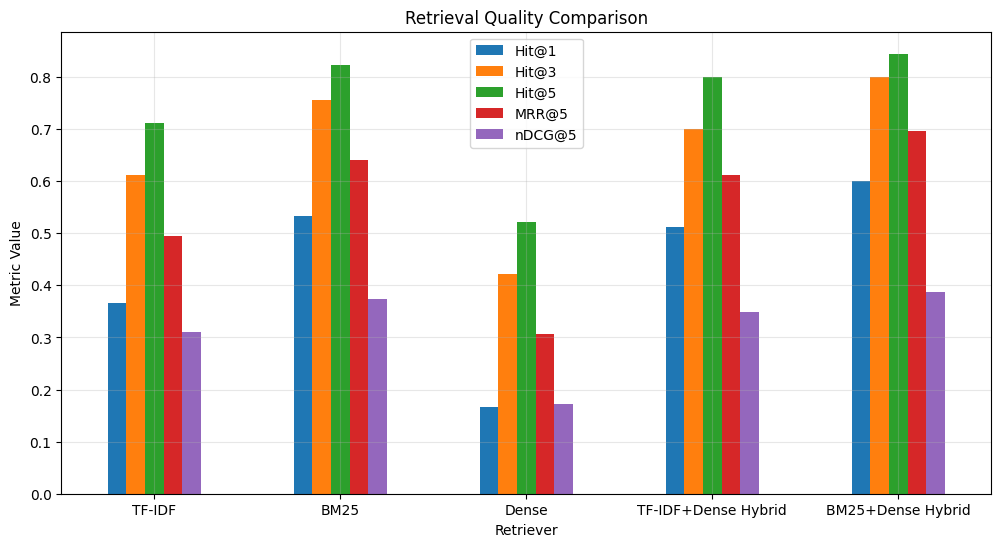

In [39]:
metrics = [
    "Hit@1",
    "Hit@3",
    "Hit@5",
    "MRR@5",
    "nDCG@5",
]

ax = (summary_df.set_index("Retriever")[metrics].plot(kind="bar", figsize=(12, 6)))
plt.title("Retrieval Quality Comparison")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.legend(loc="best")

plt.show()

In [40]:
summary_df.style.highlight_max(
    subset=[
        "Hit@1",
        "Hit@3",
        "Hit@5",
        "MRR@5",
        "nDCG@5",
    ],
    color="lightgreen",
)

,Retriever,Hit@1,Hit@3,Hit@5,MRR@5,nDCG@5
0,TF-IDF,0.366667,0.611111,0.711111,0.494259,0.310019
1,BM25,0.533333,0.755556,0.822222,0.640926,0.374552
2,Dense,0.166667,0.422222,0.522222,0.306667,0.171645
3,TF-IDF+Dense Hybrid,0.511111,0.700000,0.800000,0.611667,0.348907
4,BM25+Dense Hybrid,0.600000,0.800000,0.844444,0.696481,0.387083


## 19. Example Analysis

In [41]:
query = benchmark_queries[0]["query"]

print("QUERY:")
print(query)

print("\nTF-IDF:")
for doc in tfidf_search(query):
    print(doc.metadata["id"])

print("\nBM25:")
for doc in bm25_search(query):
    print(doc.metadata["id"])

print("\nDENSE:")
for doc in dense_search(query):
    print(doc.metadata["id"])

print("\nTF-IDF+DENSE HYBRID:")
for doc in tfidf_dense_hybrid_search(query):
    print(doc.metadata["id"])

print("\nBM25+DENSE HYBRID:")
for doc in bm25_dense_hybrid_search(query):
    print(doc.metadata["id"])

QUERY:
Какие есть ставки налога для самозанятых в зависимости от типа покупателя?

TF-IDF:
doc_079
doc_017
doc_001
doc_014
doc_014

BM25:
doc_001
doc_079
doc_177
doc_014
doc_001

DENSE:
doc_041
doc_001
doc_284
doc_168
doc_001

TF-IDF+DENSE HYBRID:
doc_079
doc_001
doc_001
doc_041
doc_189

BM25+DENSE HYBRID:
doc_001
doc_079
doc_001
doc_041
doc_189
